In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ativos = pd.read_csv('dados_limpos.csv')
ativos['Date'] = pd.to_datetime(ativos['Date'])
ativos_pivotado = ativos.pivot(index='Date', columns='Ticker', values='Retorno Diário')

media = (ativos_pivotado.mean() *100) 
media



Ticker
AAPL34.SA    0.132164
BBAS3.SA     0.094128
WEGE3.SA     0.113989
^GSPC        0.031118
dtype: float64

In [3]:
ativos = pd.read_csv('dados_limpos.csv')
ativos['Date'] = pd.to_datetime(ativos['Date'])
ativos_pivotado = ativos.pivot(index='Date', columns='Ticker', values='Retorno Diário')
ativos_pivotado

Ticker,AAPL34.SA,BBAS3.SA,WEGE3.SA,^GSPC
Date,,,,
1928-01-03,NaN,NaN,NaN,0.005663
1928-01-04,NaN,NaN,NaN,-0.002252
1928-01-05,NaN,NaN,NaN,-0.009594
1928-01-06,NaN,NaN,NaN,0.006268
1928-01-09,NaN,NaN,NaN,-0.009060
...,...,...,...,...
2026-03-27,-0.019900,-0.017346,-0.002315,-0.016722
2026-03-30,-0.003230,-0.011474,0.034592,-0.003946
2026-03-31,0.020062,0.026786,0.039959,0.029131


# Período Máximo

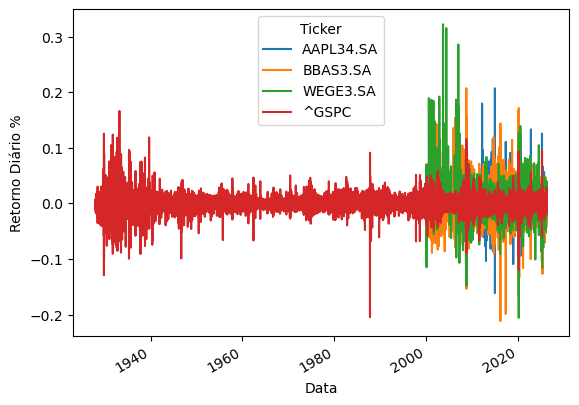

In [4]:
#período total
ativos_pivotado.plot()
plt.xlabel("Data")
plt.ylabel('Retorno Diário %')
plt.show()

In [21]:
matrix_covariancia_anualizada = ativos_pivotado.cov()*252
matrix_covariancia_anualizada

Ticker,AAPL34.SA,BBAS3.SA,WEGE3.SA,^GSPC
Ticker,,,,
AAPL34.SA,0.106024,-0.006054,0.007266,0.020835
BBAS3.SA,-0.006054,0.170216,0.030359,0.029631
WEGE3.SA,0.007266,0.030359,0.109339,0.016400
^GSPC,0.020835,0.029631,0.016400,0.035831


In [22]:
correlacao = ativos_pivotado.corr()
correlacao

Ticker,AAPL34.SA,BBAS3.SA,WEGE3.SA,^GSPC
Ticker,,,,
AAPL34.SA,1.000000,-0.047510,0.071021,0.379105
BBAS3.SA,-0.047510,1.000000,0.222533,0.370365
WEGE3.SA,0.071021,0.222533,1.000000,0.259061
^GSPC,0.379105,0.370365,0.259061,1.000000


# Período Selecionado

In [17]:
ativos_tempo_selecionado = ativos_pivotado.loc['2022-01-01':]
ativos_tempo_selecionado

Ticker,AAPL34.SA,BBAS3.SA,WEGE3.SA,^GSPC
Date,,,,
2022-01-03,0.046618,-0.001040,-0.029109,0.006374
2022-01-04,-0.007150,0.001041,-0.004997,-0.000630
2022-01-05,-0.025691,-0.016638,-0.052731,-0.019393
2022-01-06,-0.026069,0.008107,-0.000332,-0.000964
2022-01-07,0.001846,0.001049,-0.025190,-0.004050
...,...,...,...,...
2026-03-27,-0.019900,-0.017346,-0.002315,-0.016722
2026-03-30,-0.003230,-0.011474,0.034592,-0.003946
2026-03-31,0.020062,0.026786,0.039959,0.029131


In [18]:
ativos_tempo_selecionado.mean()

Ticker
AAPL34.SA    0.000453
BBAS3.SA     0.000913
WEGE3.SA     0.000678
^GSPC        0.000364
dtype: float64

In [19]:
retorno_acumulado = (1 + ativos_tempo_selecionado.fillna(0)).cumprod()
retorno_acumulado = (retorno_acumulado.iloc[-1]-1)*100
retorno_acumulado 


Ticker
AAPL34.SA     35.489516
BBAS3.SA     127.107408
WEGE3.SA      69.783240
^GSPC         38.112486
Name: 2026-04-02 00:00:00, dtype: float64

# Fronteira Eficiente

In [23]:
# 1. Estatísticas Anualizadas
retornos_anuais = ativos_pivotado.mean() * 252
matriz_cov = ativos_pivotado.cov() * 252

# Lista para guardar os resultados das simulações
resultados = []
pesos_lista = []
num_ativos = len(ativos_pivotado.columns)
num_portfolios = 10000 # Quantas combinações vamos testar

In [24]:
for i in range(num_portfolios):
    # Gerar pesos aleatórios que somam 100% (1.0)
    pesos = np.random.random(num_ativos)
    pesos /= np.sum(pesos)
    pesos_lista.append(pesos)
    
    # Cálculo do Retorno Esperado da Carteira
    retorno = np.dot(pesos, retornos_anuais)
    
    # Cálculo da Volatilidade (Risco) da Carteira
    # Fórmula: sqrt( pesos.T * cov * pesos )
    volatilidade = np.sqrt(np.dot(pesos.T, np.dot(matriz_cov, pesos)))
    
    # Índice de Sharpe (assumindo taxa livre de risco = 0 para simplificar)
    sharpe = retorno / volatilidade
    
    resultados.append([retorno, volatilidade, sharpe])

# Criar DataFrame com as simulações
portfolios = pd.DataFrame(resultados, columns=['Retorno', 'Volatilidade', 'Sharpe'])

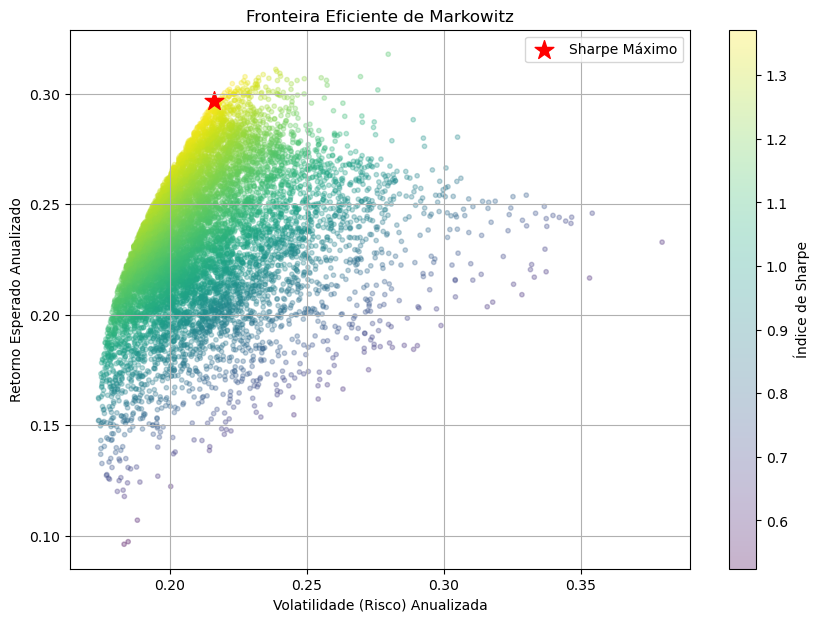

Pesos Recomendados para o Sharpe Máximo:
AAPL34.SA: 47.49%
BBAS3.SA: 17.65%
WEGE3.SA: 33.20%
^GSPC: 1.66%


In [25]:
plt.figure(figsize=(10, 7))
plt.scatter(portfolios['Volatilidade'], portfolios['Retorno'], c=portfolios['Sharpe'], cmap='viridis', s=10, alpha=0.3)
plt.colorbar(label='Índice de Sharpe')

# Identificar o Portfólio de Sharpe Máximo (Melhor relação Risco x Retorno)
melhor_sharpe_idx = portfolios['Sharpe'].idxmax()
plt.scatter(portfolios.loc[melhor_sharpe_idx, 'Volatilidade'], 
            portfolios.loc[melhor_sharpe_idx, 'Retorno'], 
            c='red', marker='*', s=200, label='Sharpe Máximo')

plt.title('Fronteira Eficiente de Markowitz')
plt.xlabel('Volatilidade (Risco) Anualizada')
plt.ylabel('Retorno Esperado Anualizado')
plt.legend()
plt.grid(True)
plt.show()

# Ver os pesos do melhor portfólio
print("Pesos Recomendados para o Sharpe Máximo:")
for ativo, peso in zip(ativos_pivotado.columns, pesos_lista[melhor_sharpe_idx]):
    print(f"{ativo}: {peso:.2%}")